# HP k=20-45 Comprehensive Comparison (TF-IDF > 1000)

Compare KmerSeek HP with k-mer sizes from 20 to 45, using consistent TF-IDF > 1000 threshold.

Goals:
1. Load all HP k=20-45 results
2. Analyze metrics distributions across k-values
3. Compute sensitivity curves for all k-values (TF-IDF > 1000)
4. Performance summary (n_comparisons, n_queries, coverage)
5. Analyze n_intersecting_hashes distributions
6. Identify k-values that outperform FoldSeek/TEA (AUC >= 0.58)

In [41]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from glob import glob

# Add notebooks directory to path for imports
sys.path.append(str(Path.cwd()))

from scope_kmerseek_utils import (
    add_scope_hierarchical_levels,
    load_rocx_file,
    kmerseek_to_rocx,
    plot_sensitivity_from_rocx,
    compute_auc,
    read_csv_with_size_limit
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Load All HP k=20-30 Data

In [42]:
# Define paths
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")

# Find all HP k=20-30 result files
k_values = list(range(20, 45 + 1))
hp_files = {}

for k in k_values:
    pattern = f"*hp.k{k}.scaled1.kmerseek.results.csv"
    files = list(data_dir.glob(pattern))
    if files:
        hp_files[k] = files[0]
        print(f"k={k}: {files[0].name}")
    else:
        print(f"k={k}: NOT FOUND")

print(f"\nFound {len(hp_files)} k-values: {sorted(hp_files.keys())}")

k=20: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv
k=21: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k21.scaled1.kmerseek.results.csv
k=22: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k22.scaled1.kmerseek.results.csv
k=23: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k23.scaled1.kmerseek.results.csv
k=24: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k24.scaled1.kmerseek.results.csv
k=25: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k25.scaled1.kmerseek.results.csv
k=26: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k26.scaled1.kmerseek.results.csv
k=27: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k27.scaled1.kmerseek.results.csv
k=28: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k28.scaled1.kmerseek.results.csv
k=29: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k29.scaled1.kmerseek.results.csv
k=30: astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k30.scaled1.kmerseek.results.csv
k=31: astr

In [43]:
# Load all data - for larger k values, read full files since they're smaller
hp_data = {}
hp_stats = []

for k, filepath in sorted(hp_files.items()):
    print(f"\nLoading HP k={k}...")
    
    # For k>=25, files are small enough to load entirely
    if k >= 25:
        df = pl.read_csv(filepath)
        print(f"  Loaded full file: {df.shape[0]:,} rows")
    else:
        # For smaller k, use size limit
        df = read_csv_with_size_limit(filepath, max_rows=15_000_000, size_threshold_gb=1.0)
        print(f"  Loaded limited rows: {df.shape[0]:,} rows")
    
    # Add SCOPe hierarchical levels
    df = add_scope_hierarchical_levels(df)
    
    # Store
    hp_data[k] = df
    
    # Collect statistics
    n_queries = df['query_name'].n_unique()
    n_targets = df['target_name'].n_unique()
    n_comparisons = len(df)
    n_family_matches = df.filter(pl.col('family_match')).shape[0]
    n_superfamily_matches = df.filter(pl.col('superfamily_match')).shape[0]
    
    hp_stats.append({
        'k': k,
        'n_queries': n_queries,
        'n_targets': n_targets,
        'n_comparisons': n_comparisons,
        'n_family_matches': n_family_matches,
        'n_superfamily_matches': n_superfamily_matches,
        'pct_family': n_family_matches / n_comparisons * 100,
        'pct_superfamily': n_superfamily_matches / n_comparisons * 100
    })
    
    print(f"  Queries: {n_queries:,}")
    print(f"  Targets: {n_targets:,}")
    print(f"  Comparisons: {n_comparisons:,}")
    print(f"  Family matches: {n_family_matches:,} ({n_family_matches/n_comparisons*100:.2f}%)")
    print(f"  Superfamily matches: {n_superfamily_matches:,} ({n_superfamily_matches/n_comparisons*100:.2f}%)")


Loading HP k=20...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv (1.82 GB) - reading first 15,000,000 rows...
  Loaded limited rows: 3,563,401 rows
  Queries: 15,174
  Targets: 15,174
  Comparisons: 3,563,401
  Family matches: 16,347 (0.46%)
  Superfamily matches: 38,899 (1.09%)

Loading HP k=21...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k21.scaled1.kmerseek.results.csv (0.91 GB) - reading all rows...
  Loaded limited rows: 1,781,091 rows
  Queries: 15,163
  Targets: 15,163
  Comparisons: 1,781,091
  Family matches: 10,072 (0.57%)
  Superfamily matches: 22,576 (1.27%)

Loading HP k=22...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k22.scaled1.kmerseek.results.csv (0.46 GB) - reading all rows...
  Loaded limited rows: 890,968 rows
  Queries: 15,136
  Targets: 15,136
  Comparisons: 890,968
  Family matches: 6,285 (0.71%)
  Superfamily matches: 13,527 (1.52%)

Loading HP k=23...
Loading astral-scopedom-seqres

## 2. Performance Summary Statistics

In [44]:
# Create summary DataFrame
summary_df = pl.DataFrame(hp_stats)
print("\nPerformance Summary Across k-values:")
print(summary_df)


Performance Summary Across k-values:
shape: (26, 8)
┌─────┬───────────┬───────────┬─────────────┬─────────────┬─────────────┬────────────┬─────────────┐
│ k   ┆ n_queries ┆ n_targets ┆ n_compariso ┆ n_family_ma ┆ n_superfami ┆ pct_family ┆ pct_superfa │
│ --- ┆ ---       ┆ ---       ┆ ns          ┆ tches       ┆ ly_matches  ┆ ---        ┆ mily        │
│ i64 ┆ i64       ┆ i64       ┆ ---         ┆ ---         ┆ ---         ┆ f64        ┆ ---         │
│     ┆           ┆           ┆ i64         ┆ i64         ┆ i64         ┆            ┆ f64         │
╞═════╪═══════════╪═══════════╪═════════════╪═════════════╪═════════════╪════════════╪═════════════╡
│ 20  ┆ 15174     ┆ 15174     ┆ 3563401     ┆ 16347       ┆ 38899       ┆ 0.458747   ┆ 1.091626    │
│ 21  ┆ 15163     ┆ 15163     ┆ 1781091     ┆ 10072       ┆ 22576       ┆ 0.565496   ┆ 1.267538    │
│ 22  ┆ 15136     ┆ 15136     ┆ 890968      ┆ 6285        ┆ 13527       ┆ 0.705413   ┆ 1.518236    │
│ 23  ┆ 15053     ┆ 15053     ┆ 445291

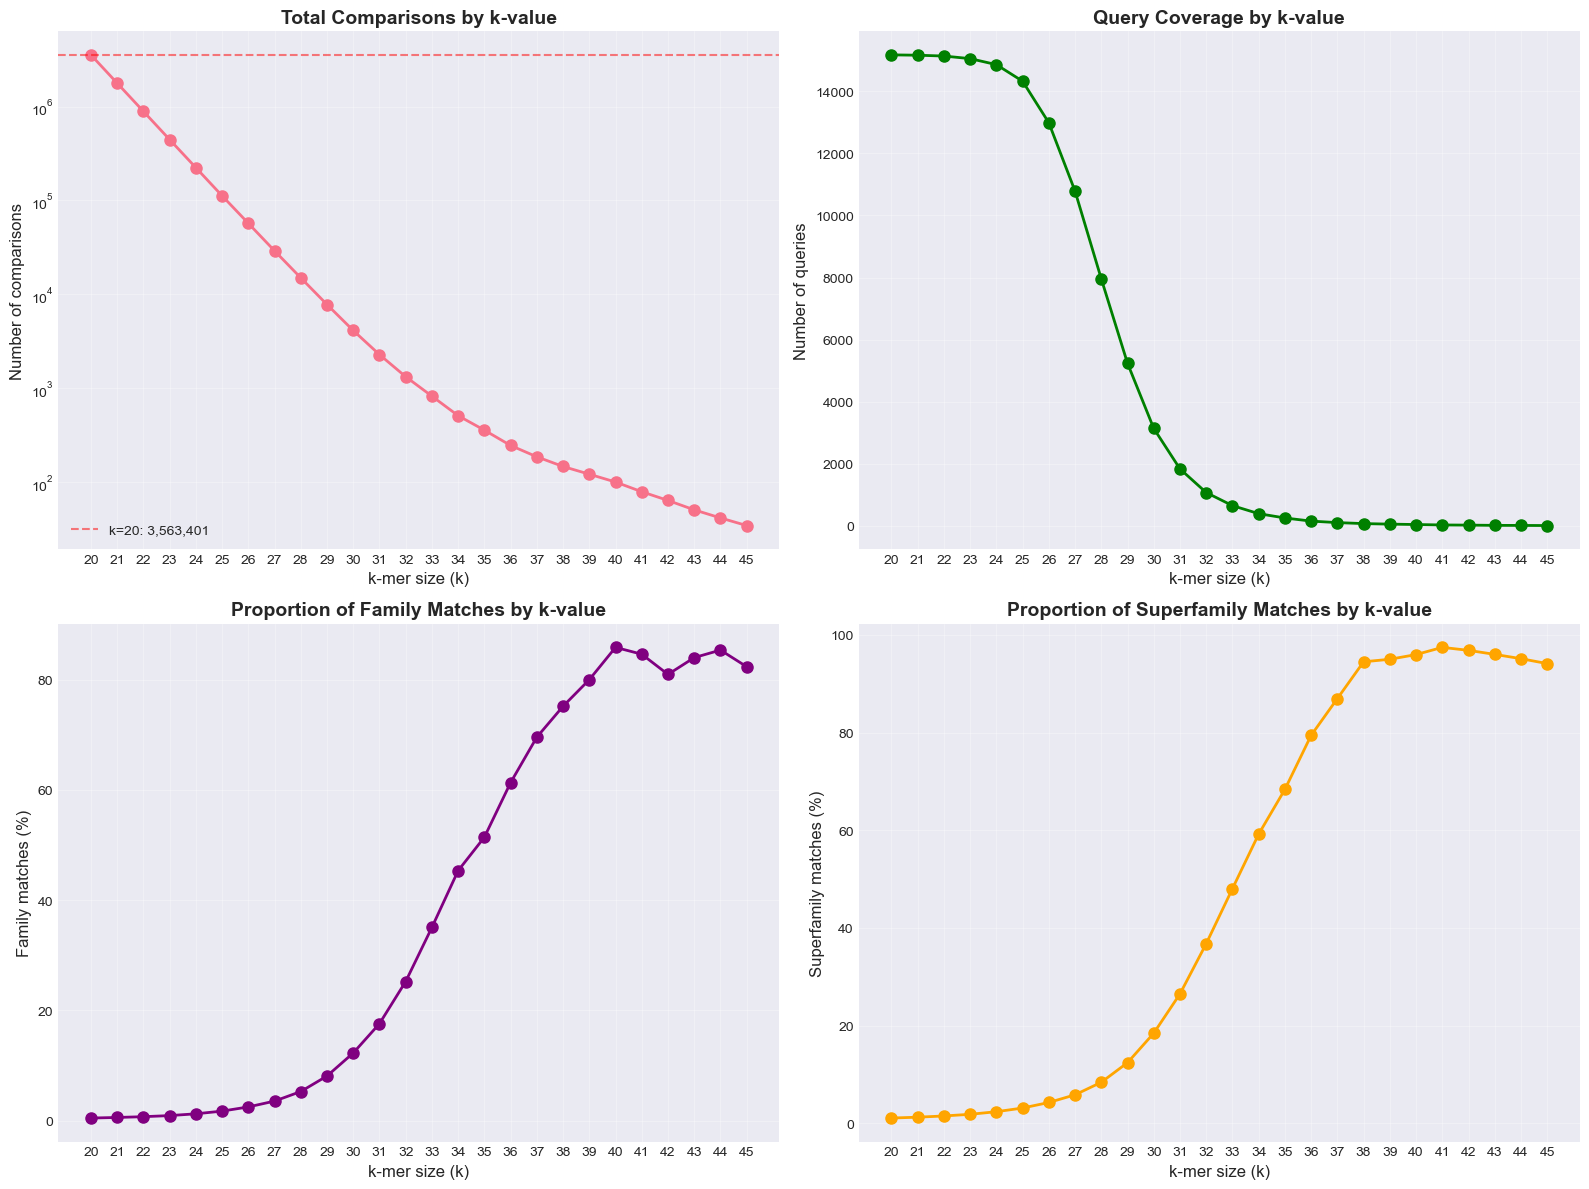

In [45]:
# Visualize performance summary
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Number of comparisons
ax = axes[0, 0]
ax.plot(summary_df['k'], summary_df['n_comparisons'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('Number of comparisons', fontsize=12)
ax.set_title('Total Comparisons by k-value', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.set_xticks(summary_df['k'])

# Add annotation for k=20
k20_comparisons = summary_df.filter(pl.col('k') == 20)['n_comparisons'][0]
ax.axhline(k20_comparisons, color='red', linestyle='--', alpha=0.5, label=f'k=20: {k20_comparisons:,}')
ax.legend(fontsize=10)

# Plot 2: Number of queries
ax = axes[0, 1]
ax.plot(summary_df['k'], summary_df['n_queries'], 'o-', linewidth=2, markersize=8, color='green')
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('Number of queries', fontsize=12)
ax.set_title('Query Coverage by k-value', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(summary_df['k'])

# Plot 3: Percentage of family matches
ax = axes[1, 0]
ax.plot(summary_df['k'], summary_df['pct_family'], 'o-', linewidth=2, markersize=8, color='purple')
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('Family matches (%)', fontsize=12)
ax.set_title('Proportion of Family Matches by k-value', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(summary_df['k'])

# Plot 4: Percentage of superfamily matches
ax = axes[1, 1]
ax.plot(summary_df['k'], summary_df['pct_superfamily'], 'o-', linewidth=2, markersize=8, color='orange')
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('Superfamily matches (%)', fontsize=12)
ax.set_title('Proportion of Superfamily Matches by k-value', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xticks(summary_df['k'])

plt.tight_layout()
plt.savefig('hp_k20_30_performance_summary.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 3. Intersecting Hashes Distribution

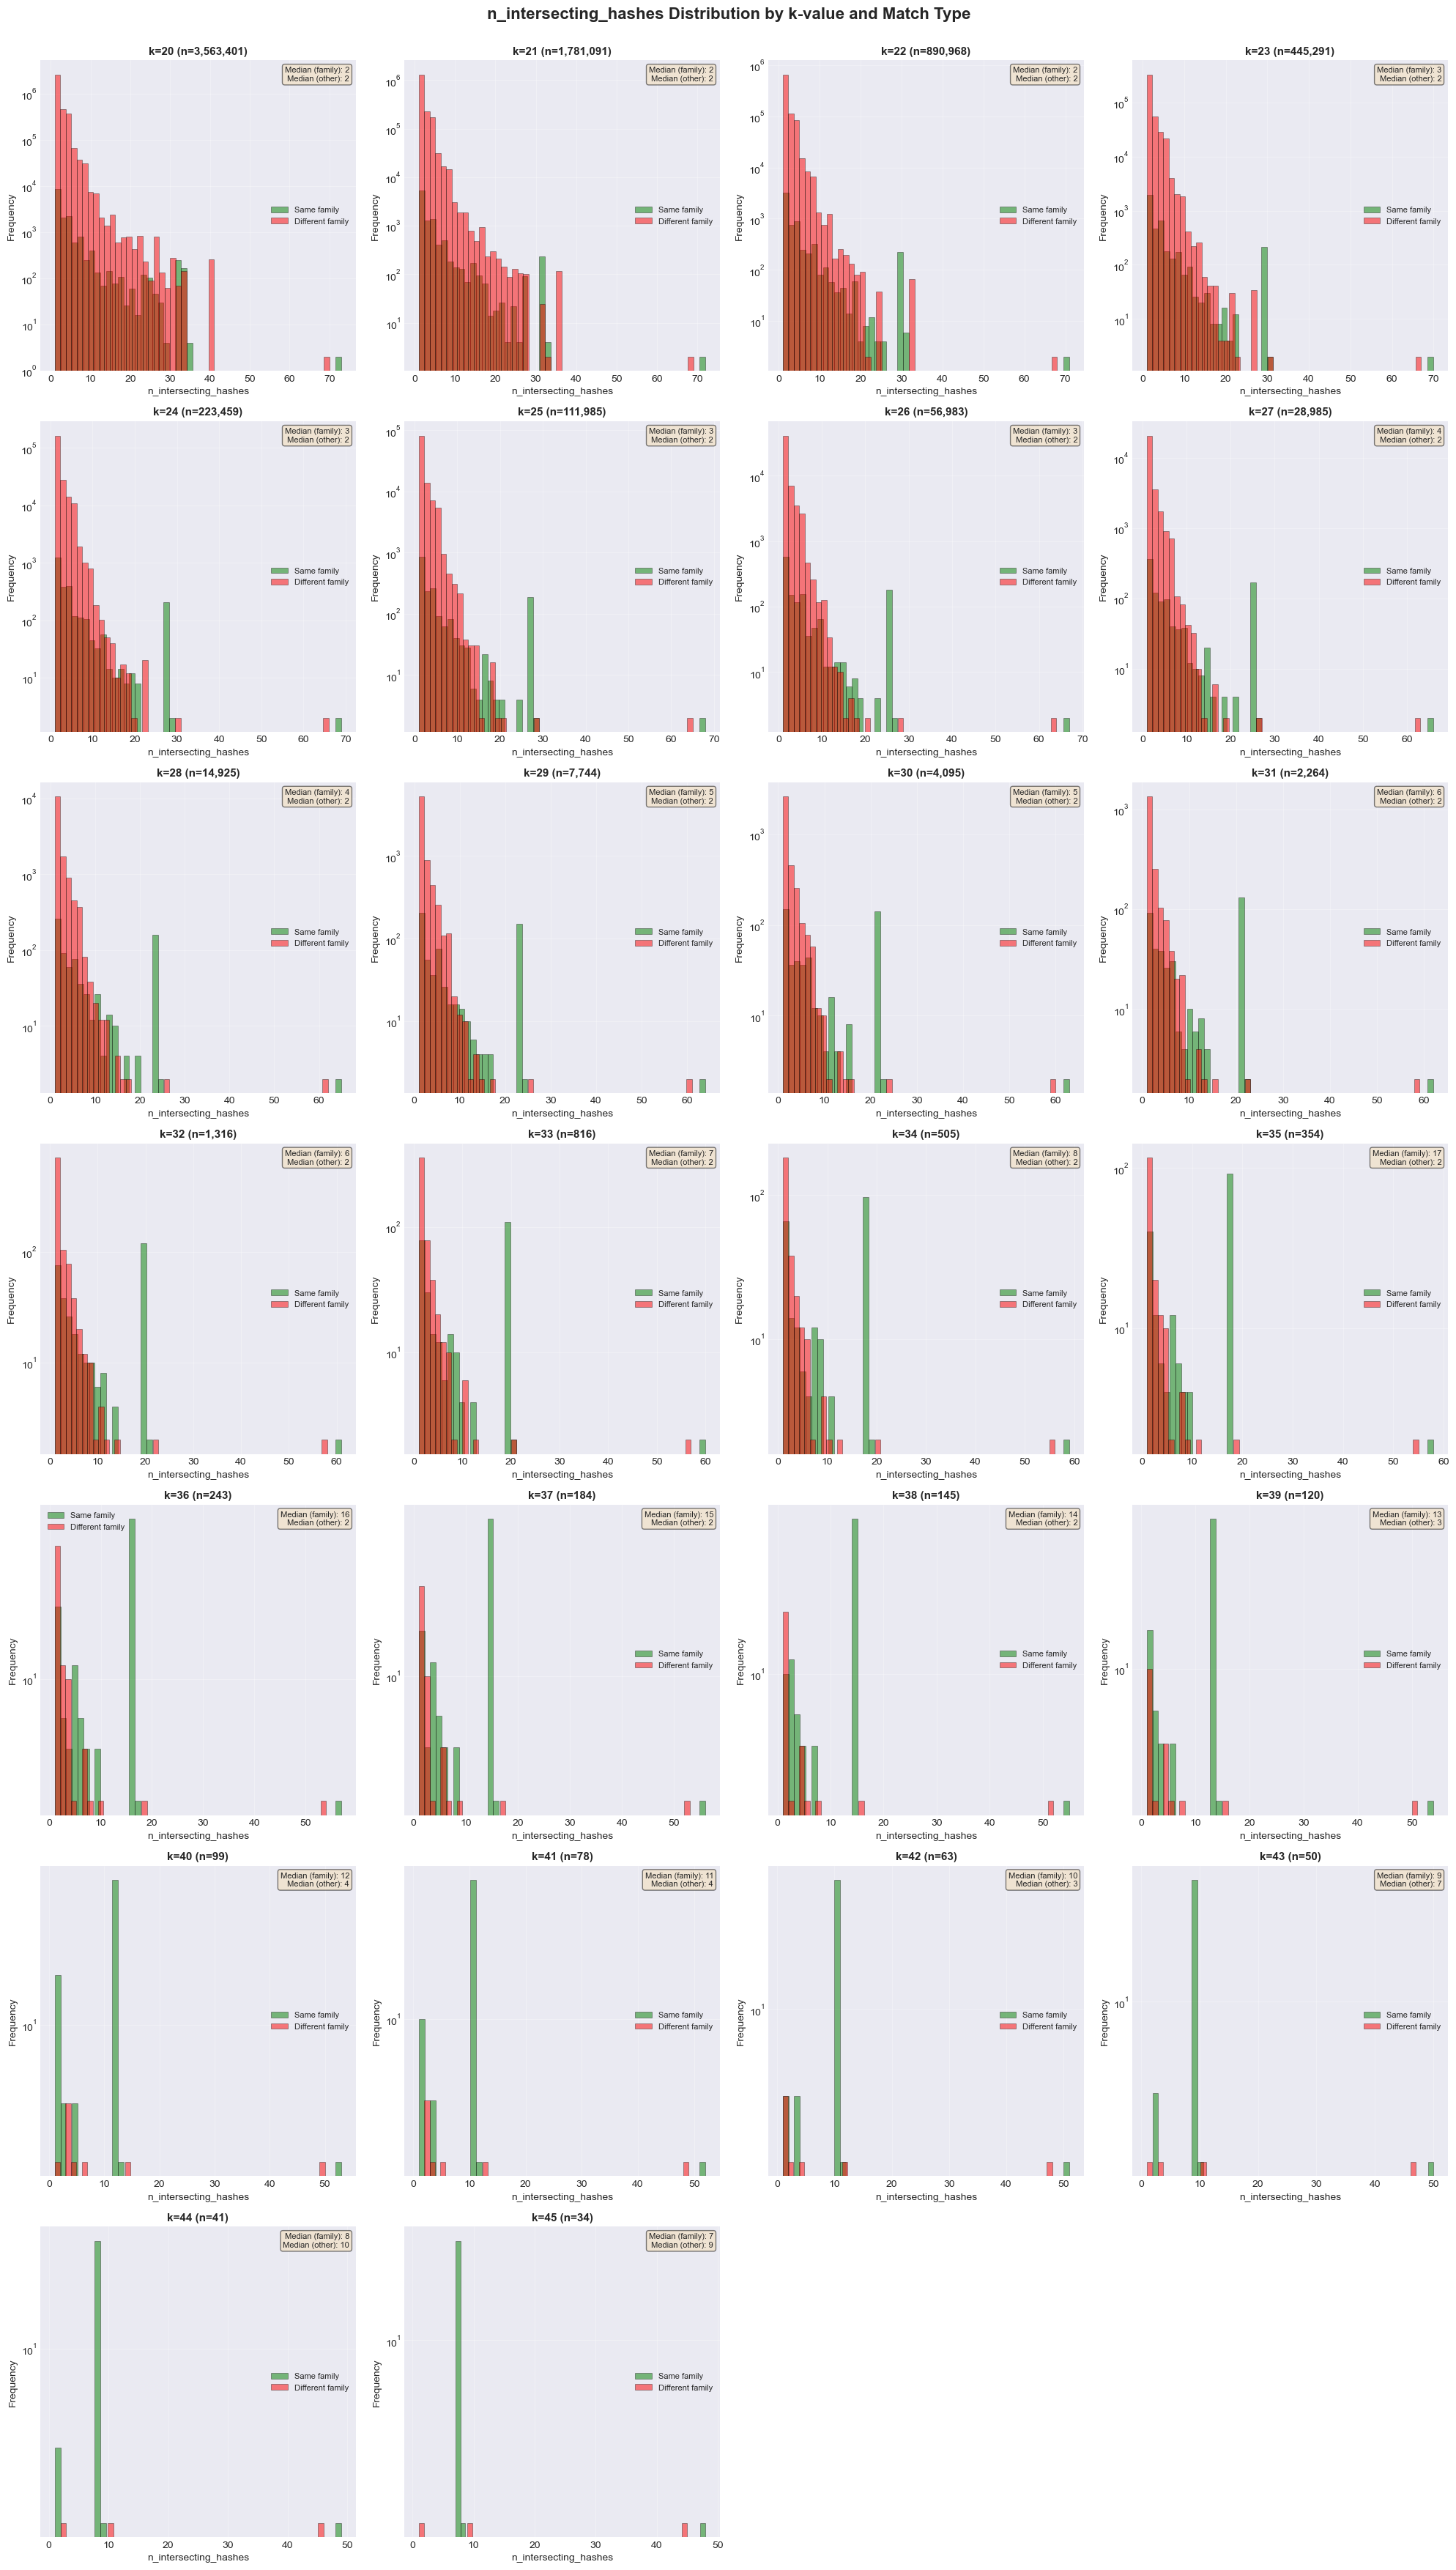

In [46]:
# Analyze n_intersecting_hashes distribution for each k
# Dynamically calculate grid size based on number of k-values
n_k_values = len(hp_data)
n_cols = 4
n_rows = (n_k_values + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for idx, k in enumerate(sorted(hp_data.keys())):
    ax = axes[idx]
    df = hp_data[k]
    
    # Get intersecting hashes for family matches vs non-matches
    family_hashes = df.filter(pl.col('family_match'))['n_intersecting_hashes'].to_numpy()
    non_family_hashes = df.filter(~pl.col('family_match'))['n_intersecting_hashes'].to_numpy()
    
    # Plot histograms
    ax.hist(family_hashes, bins=50, alpha=0.5, label='Same family', color='green', edgecolor='black', linewidth=0.5)
    ax.hist(non_family_hashes, bins=50, alpha=0.5, label='Different family', color='red', edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('n_intersecting_hashes', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'k={k} (n={len(df):,})', fontsize=11, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Add statistics as text
    family_median = np.median(family_hashes)
    non_family_median = np.median(non_family_hashes)
    ax.text(0.98, 0.98, f'Median (family): {family_median:.0f}\nMedian (other): {non_family_median:.0f}',
            transform=ax.transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide extra subplots if any
for idx in range(n_k_values, len(axes)):
    axes[idx].axis('off')

plt.suptitle('n_intersecting_hashes Distribution by k-value and Match Type', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('hp_k20_30_intersecting_hashes.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [47]:
# Summary statistics for n_intersecting_hashes by k-value
hash_stats = []

for k in sorted(hp_data.keys()):
    df = hp_data[k]
    
    # Overall
    all_hashes = df['n_intersecting_hashes']
    
    # By match type
    family_hashes = df.filter(pl.col('family_match'))['n_intersecting_hashes']
    non_family_hashes = df.filter(~pl.col('family_match'))['n_intersecting_hashes']
    
    hash_stats.append({
        'k': k,
        'all_median': all_hashes.median(),
        'all_mean': all_hashes.mean(),
        'all_max': all_hashes.max(),
        'family_median': family_hashes.median(),
        'family_mean': family_hashes.mean(),
        'family_max': family_hashes.max(),
        'non_family_median': non_family_hashes.median(),
        'non_family_mean': non_family_hashes.mean(),
        'non_family_max': non_family_hashes.max()
    })

hash_summary = pl.DataFrame(hash_stats)
print("\nn_intersecting_hashes Summary:")
print(hash_summary)


n_intersecting_hashes Summary:
shape: (26, 10)
┌─────┬────────────┬───────────┬─────────┬───┬────────────┬─────────────┬─────────────┬────────────┐
│ k   ┆ all_median ┆ all_mean  ┆ all_max ┆ … ┆ family_max ┆ non_family_ ┆ non_family_ ┆ non_family │
│ --- ┆ ---        ┆ ---       ┆ ---     ┆   ┆ ---        ┆ median      ┆ mean        ┆ _max       │
│ i64 ┆ f64        ┆ f64       ┆ i64     ┆   ┆ i64        ┆ ---         ┆ ---         ┆ ---        │
│     ┆            ┆           ┆         ┆   ┆            ┆ f64         ┆ f64         ┆ i64        │
╞═════╪════════════╪═══════════╪═════════╪═══╪════════════╪═════════════╪═════════════╪════════════╡
│ 20  ┆ 2.0        ┆ 2.171983  ┆ 73      ┆ … ┆ 73         ┆ 2.0         ┆ 2.160805    ┆ 70         │
│ 21  ┆ 2.0        ┆ 2.121368  ┆ 72      ┆ … ┆ 72         ┆ 2.0         ┆ 2.107658    ┆ 69         │
│ 22  ┆ 2.0        ┆ 2.092382  ┆ 71      ┆ … ┆ 71         ┆ 2.0         ┆ 2.07414     ┆ 68         │
│ 23  ┆ 2.0        ┆ 2.08439   ┆ 70      ┆ 

## 4. Metrics Distribution Comparison


Plotting jaccard distribution across k-values...


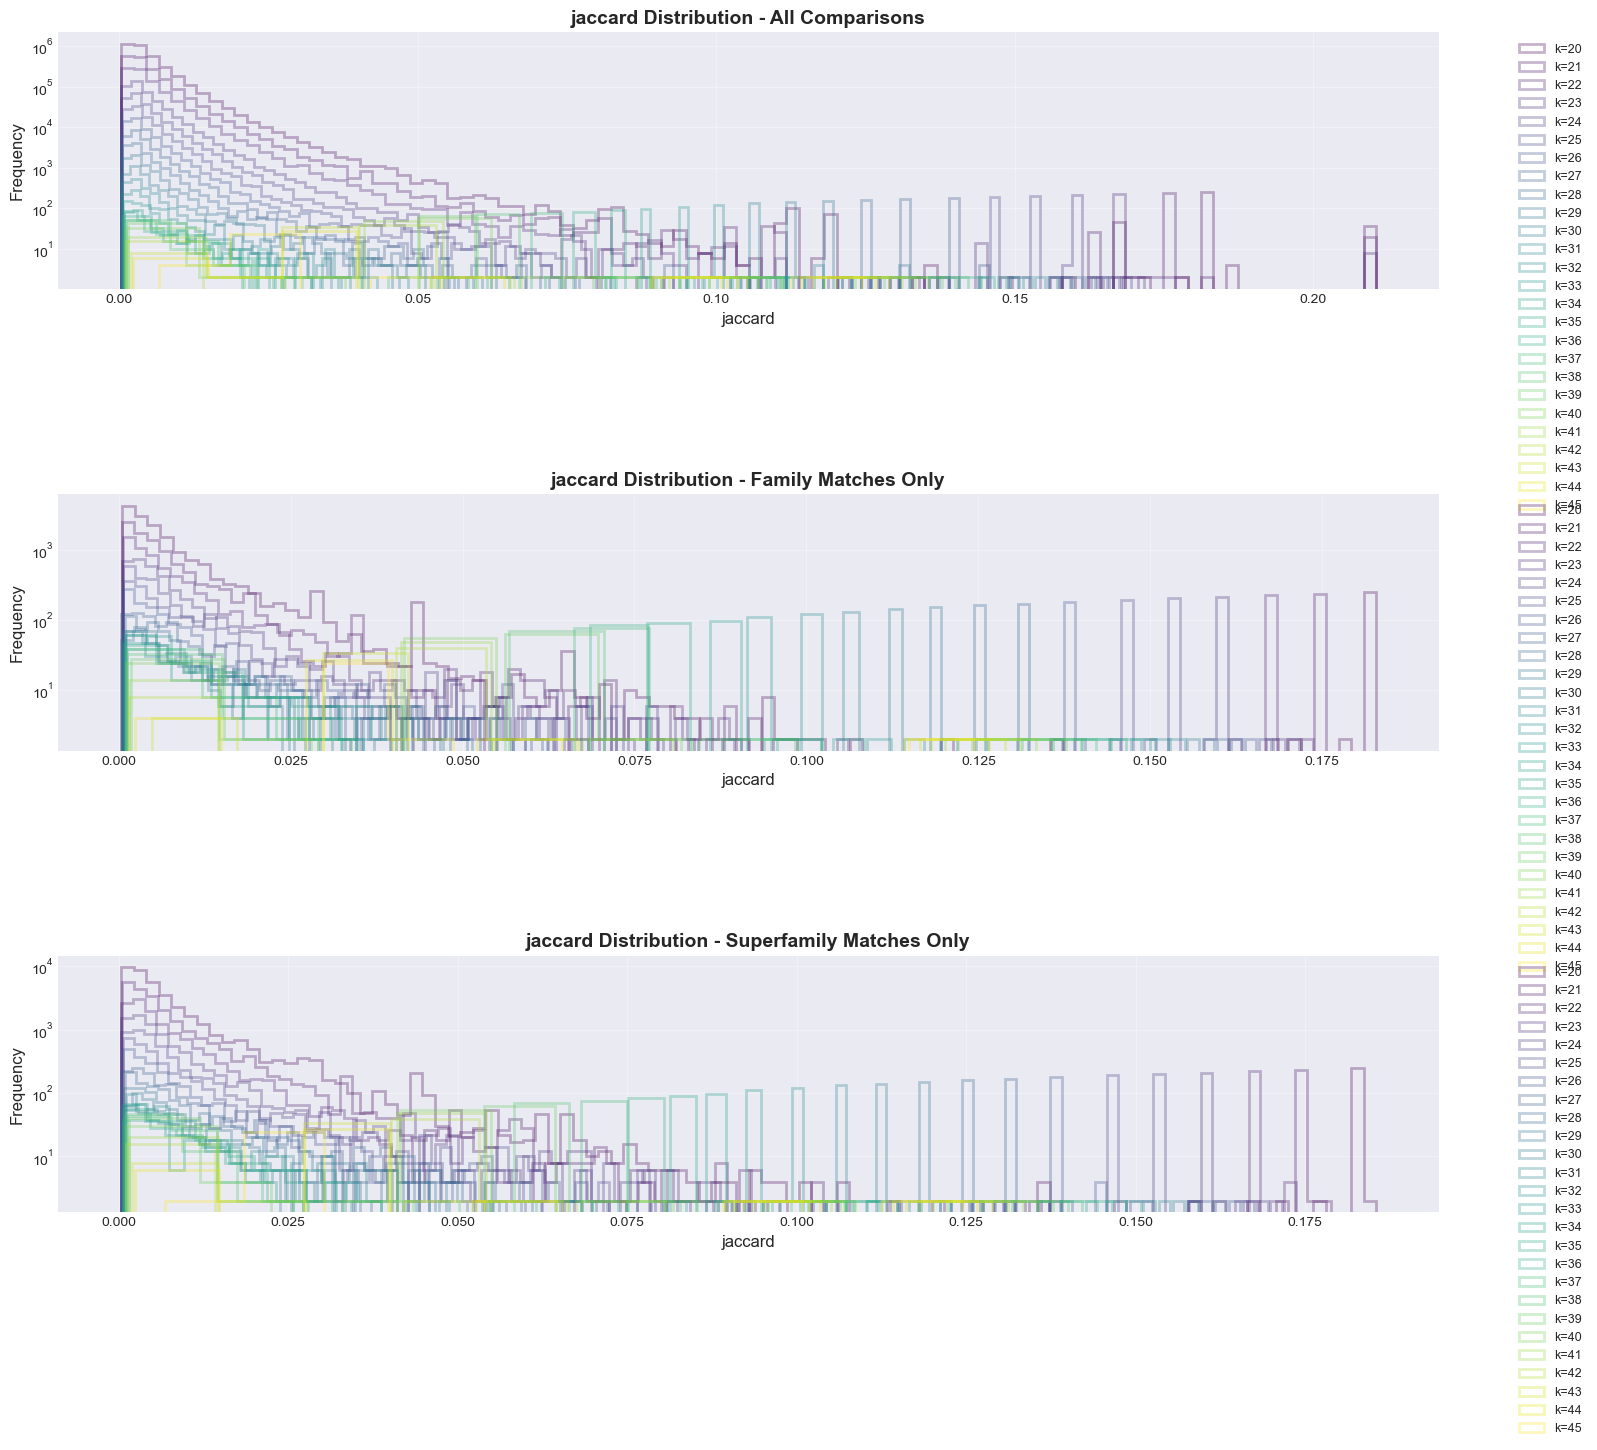


Plotting max_containment distribution across k-values...


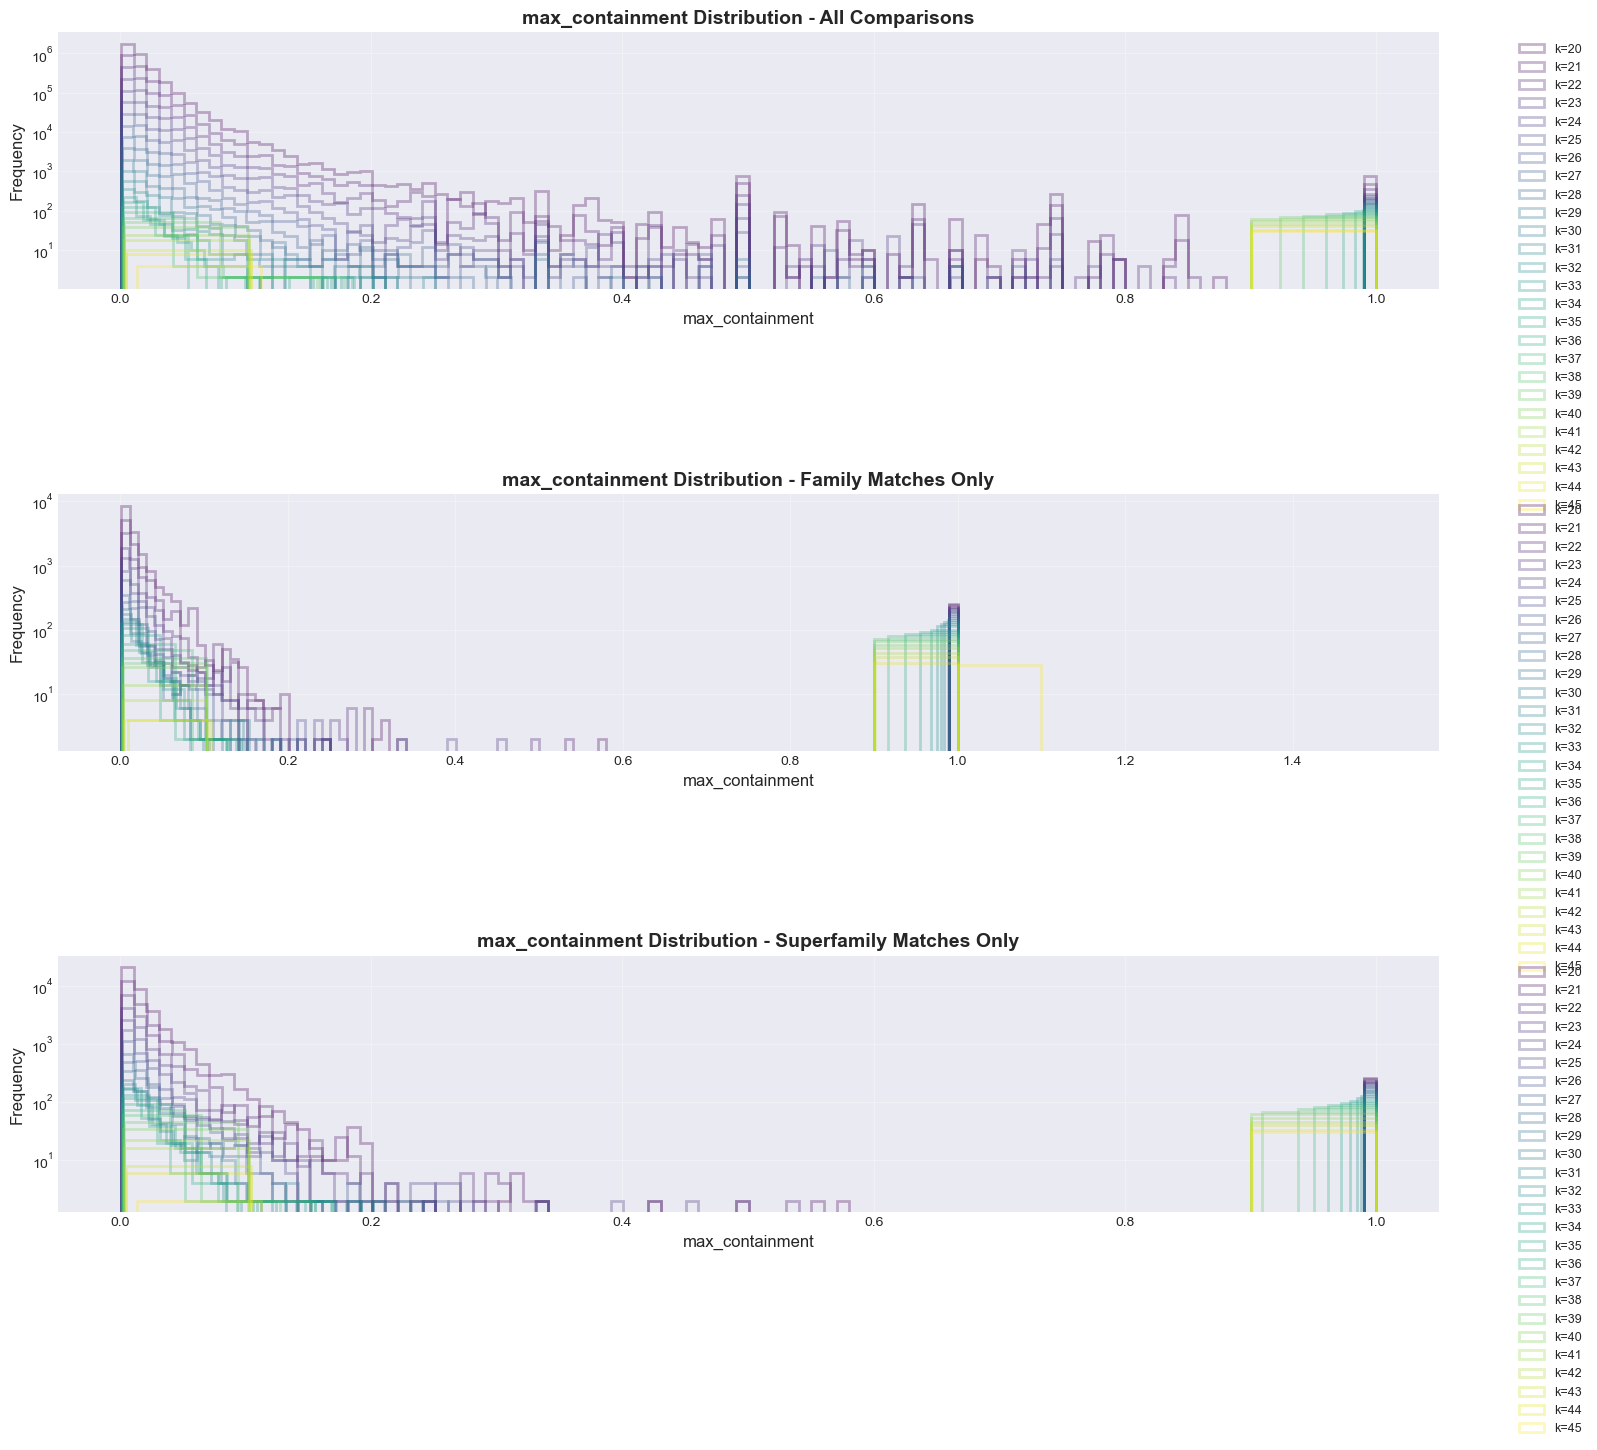


Plotting tfidf distribution across k-values...


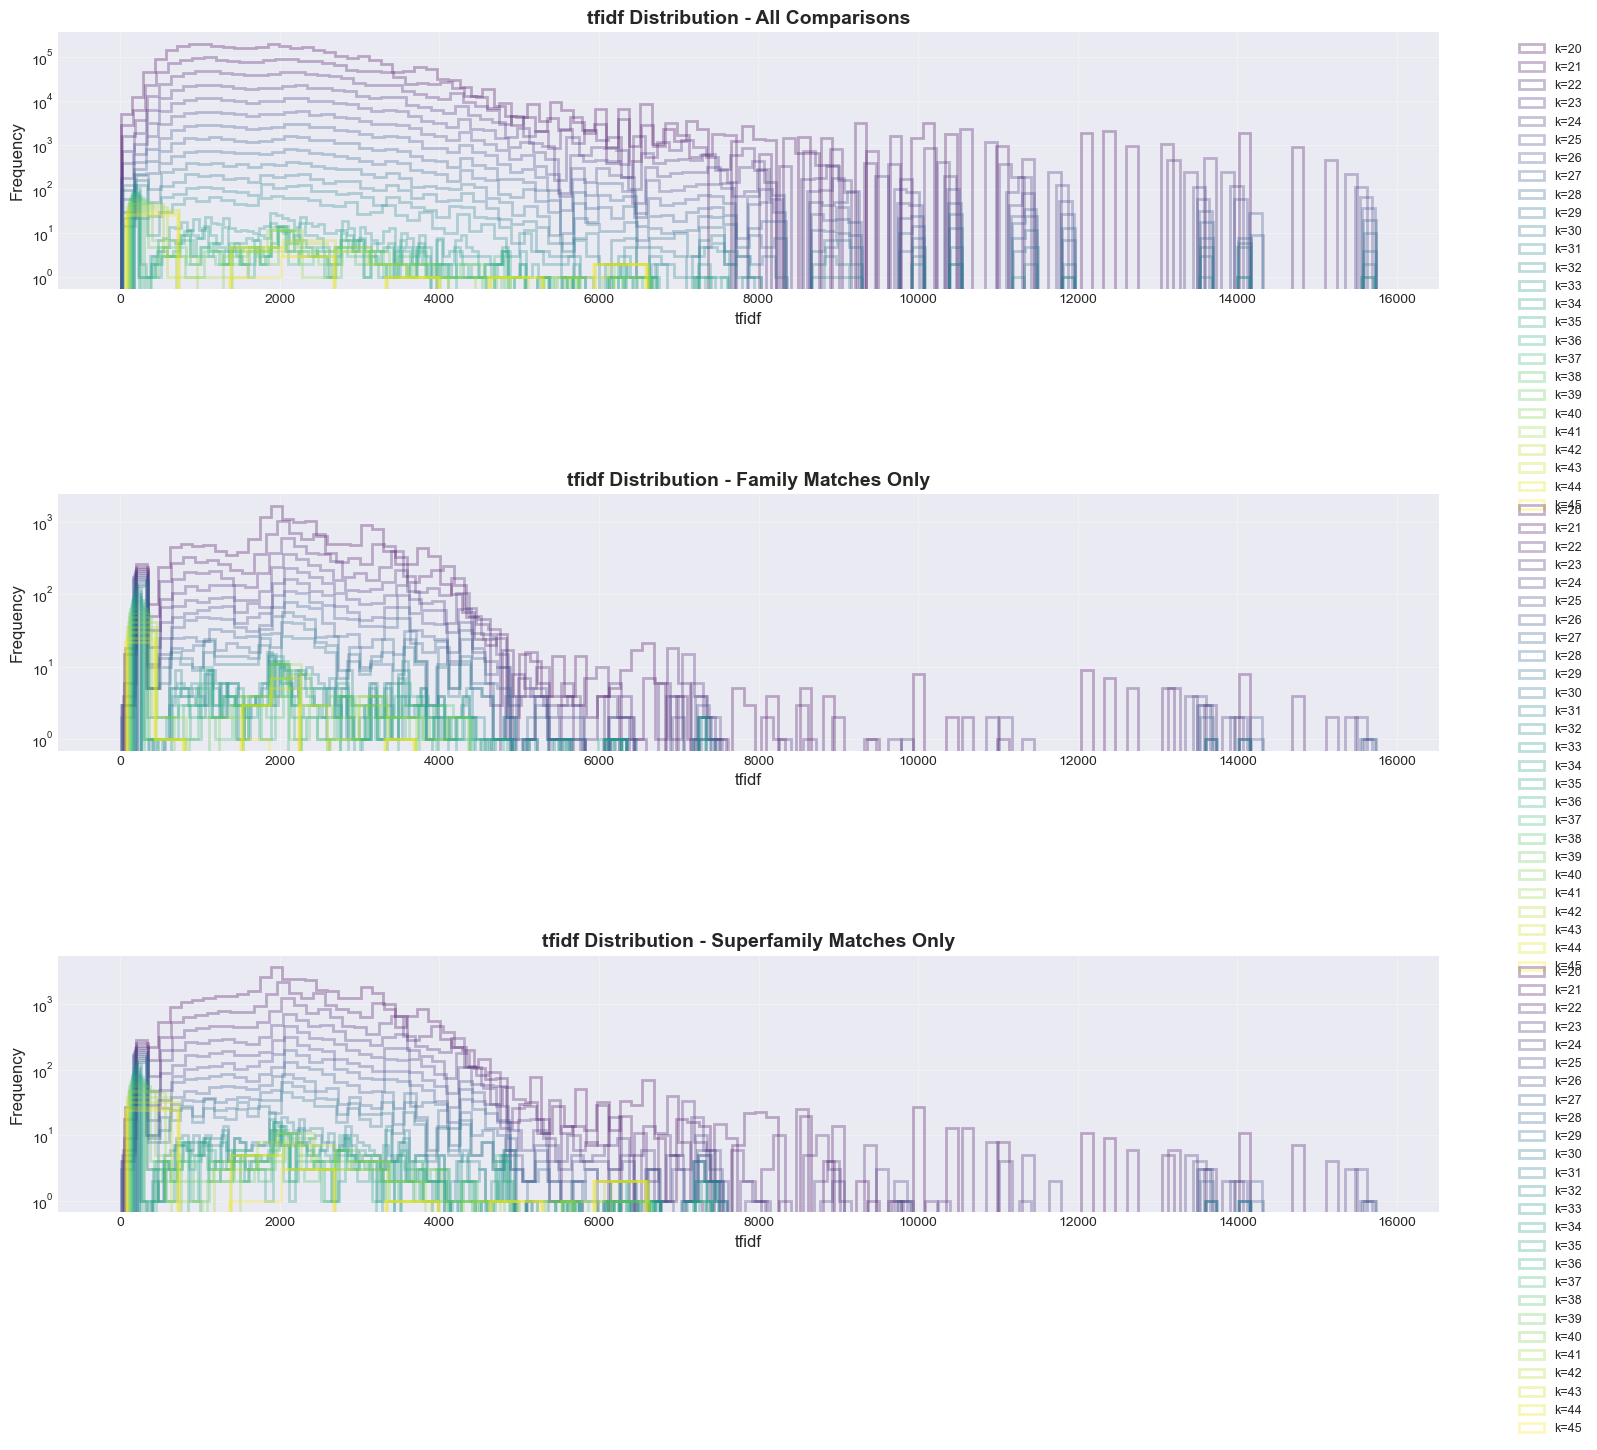


Plotting average_kmer_frequency distribution across k-values...


ValueError: Too many bins for data range. Cannot create 10 finite-sized bins.

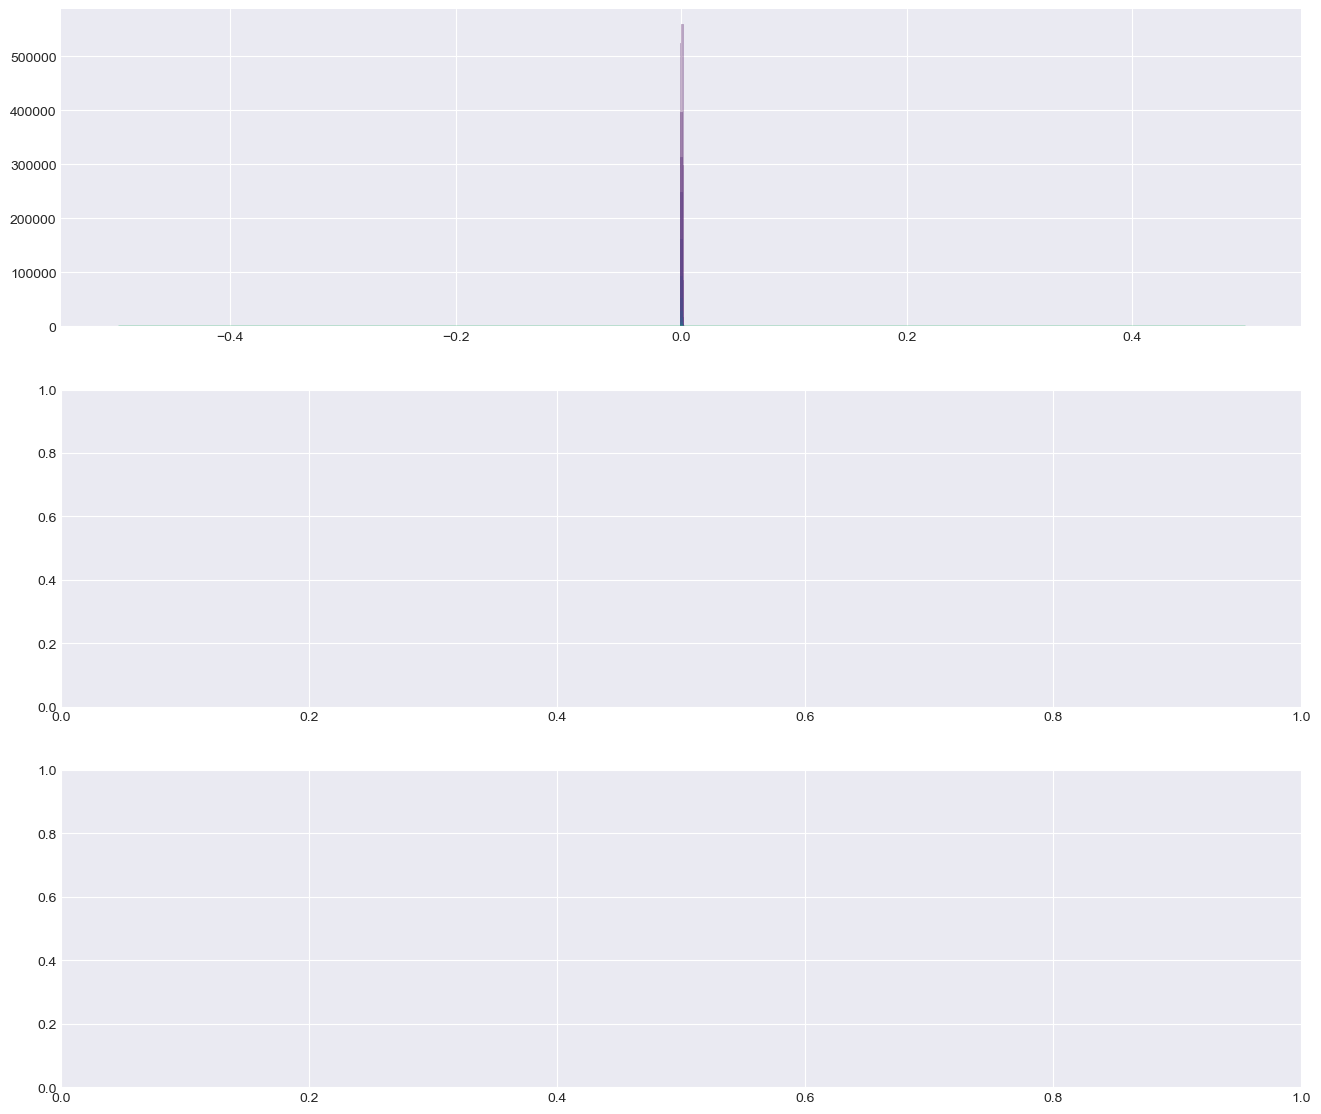

In [48]:
# Select subset of metrics to compare across k-values
metrics_to_plot = ['jaccard', 'max_containment', 'tfidf', 'average_kmer_frequency', 'observed_over_expected']

# Create colormap for k-values
import matplotlib.cm as cm
k_values_sorted = sorted(hp_data.keys())
colors = cm.viridis(np.linspace(0, 1, len(k_values_sorted)))
k_color_map = {k: colors[i] for i, k in enumerate(k_values_sorted)}

# For each metric, plot distributions across all k-values
for metric in metrics_to_plot:
    print(f"\nPlotting {metric} distribution across k-values...")
    
    fig, axes = plt.subplots(3, 1, figsize=(16, 14))
    
    # Plot 1: All comparisons
    ax = axes[0]
    for k in k_values_sorted:
        df = hp_data[k]
        values = df[metric].to_numpy()
        values = values[np.isfinite(values)]
        
        # Use adaptive bins to handle varying data ranges
        if len(values) > 0:
            n_bins = min(100, max(10, len(np.unique(values)) // 2))
            ax.hist(values, bins=n_bins, alpha=0.3, label=f'k={k}', histtype='step', 
                    linewidth=2, color=k_color_map[k])
    
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{metric} Distribution - All Comparisons', fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Family matches only
    ax = axes[1]
    for k in k_values_sorted:
        df = hp_data[k]
        values = df.filter(pl.col('family_match'))[metric].to_numpy()
        values = values[np.isfinite(values)]
        
        # Use adaptive bins to handle varying data ranges
        if len(values) > 0:
            n_bins = min(100, max(10, len(np.unique(values)) // 2))
            ax.hist(values, bins=n_bins, alpha=0.3, label=f'k={k}', histtype='step', 
                    linewidth=2, color=k_color_map[k])
    
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{metric} Distribution - Family Matches Only', fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Superfamily matches only
    ax = axes[2]
    for k in k_values_sorted:
        df = hp_data[k]
        values = df.filter(pl.col('superfamily_match'))[metric].to_numpy()
        values = values[np.isfinite(values)]
        
        # Use adaptive bins to handle varying data ranges
        if len(values) > 0:
            n_bins = min(100, max(10, len(np.unique(values)) // 2))
            ax.hist(values, bins=n_bins, alpha=0.3, label=f'k={k}', histtype='step', 
                    linewidth=2, color=k_color_map[k])
    
    ax.set_xlabel(metric, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{metric} Distribution - Superfamily Matches Only', fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'hp_k20_30_{metric}_distribution.pdf', bbox_inches='tight', dpi=300)
    plt.show()

## 5. Quantile Analysis Across Metrics and k-values

In [ ]:
# Compute quantiles for all metrics and k-values
quantile_stats = []
quantiles = [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]

for metric in metrics_to_plot:
    print(f"\n{'='*80}")
    print(f"Metric: {metric}")
    print(f"{'='*80}")
    
    for k in sorted(hp_data.keys()):
        df = hp_data[k]
        
        # Family matches
        family_values = df.filter(pl.col('family_match'))[metric]
        
        # Non-family matches
        non_family_values = df.filter(~pl.col('family_match'))[metric]
        
        for q in quantiles:
            quantile_stats.append({
                'metric': metric,
                'k': k,
                'quantile': q,
                'family_value': family_values.quantile(q),
                'non_family_value': non_family_values.quantile(q)
            })

quantile_df = pl.DataFrame(quantile_stats)
print("\nQuantile statistics computed for all metrics and k-values")
print(quantile_df.head(20))


Metric: jaccard

Metric: max_containment

Metric: tfidf

Metric: average_kmer_frequency

Metric: observed_over_expected

Quantile statistics computed for all metrics and k-values
shape: (20, 5)
┌─────────┬─────┬──────────┬──────────────┬──────────────────┐
│ metric  ┆ k   ┆ quantile ┆ family_value ┆ non_family_value │
│ ---     ┆ --- ┆ ---      ┆ ---          ┆ ---              │
│ str     ┆ i64 ┆ f64      ┆ f64          ┆ f64              │
╞═════════╪═════╪══════════╪══════════════╪══════════════════╡
│ jaccard ┆ 20  ┆ 0.25     ┆ 0.002304     ┆ 0.002179         │
│ jaccard ┆ 20  ┆ 0.5      ┆ 0.004739     ┆ 0.003571         │
│ jaccard ┆ 20  ┆ 0.75     ┆ 0.010512     ┆ 0.00627          │
│ jaccard ┆ 20  ┆ 0.9      ┆ 0.023095     ┆ 0.010435         │
│ jaccard ┆ 20  ┆ 0.95     ┆ 0.035443     ┆ 0.014085         │
│ …       ┆ …   ┆ …        ┆ …            ┆ …                │
│ jaccard ┆ 22  ┆ 0.9      ┆ 0.023377     ┆ 0.010204         │
│ jaccard ┆ 22  ┆ 0.95     ┆ 0.053118     ┆ 0.013

In [ ]:
quantile_df.filter(pl.col('k') > 40)

metric,k,quantile,family_value,non_family_value
str,i64,f64,f64,f64
"""jaccard""",41,0.25,0.049107,0.005964
"""jaccard""",41,0.5,0.049107,0.019417
"""jaccard""",41,0.75,0.049107,0.042373
"""jaccard""",41,0.9,0.049107,0.099391
"""jaccard""",41,0.95,0.070175,0.099391
…,…,…,…,…
"""observed_over_expected""",45,0.5,7393.5,7393.5
"""observed_over_expected""",45,0.75,7393.5,7393.5
"""observed_over_expected""",45,0.9,7393.5,7393.5


## 6. Convert to ROCX and Compute Sensitivity Curves

In [ ]:
# Test TF-IDF > 1000 for all k-values (consistent threshold for comparison)
tfidf_thresholds = [1000]

hp_rocx_results = {}
sensitivity_results = []

for k in sorted(hp_data.keys()):
    print(f"\n{'='*80}")
    print(f"Processing HP k={k}")
    print(f"{'='*80}")
    
    df = hp_data[k]
    hp_rocx_results[k] = {}
    
    for threshold in tfidf_thresholds:
        print(f"\n  TF-IDF threshold: {threshold}")
        
        # Filter by TF-IDF
        filtered = df.filter(pl.col('tfidf') > threshold)
        print(f"    Rows after filtering: {len(filtered):,} ({len(filtered)/len(df)*100:.1f}%)")
        
        if len(filtered) == 0:
            print(f"    Skipping - no data after filtering")
            continue
        
        # Convert to rocx
        rocx = kmerseek_to_rocx(filtered, score_col='tfidf', overlap_threshold=0.0)
        hp_rocx_results[k][threshold] = rocx
        print(f"    ROCX queries: {len(rocx)}")
        
        # Compute sensitivity
        frac, sens = plot_sensitivity_from_rocx(rocx, level_col='SFAM')
        auc = compute_auc(frac, sens)
        
        sensitivity_results.append({
            'k': k,
            'threshold': threshold,
            'n_queries': len(rocx),
            'auc': auc,
            'frac': frac,
            'sens': sens
        })
        
        print(f"    AUC: {auc:.4f}")

# Create summary DataFrame
sens_summary = pl.DataFrame([
    {k: v for k, v in d.items() if k not in ['frac', 'sens']} 
    for d in sensitivity_results
])

print("\n\nSensitivity Summary:")
print(sens_summary.sort(['k', 'threshold']))


Processing HP k=20

  TF-IDF threshold: 1000
    Rows after filtering: 2,891,093 (81.1%)
    ROCX queries: 8563
    AUC: 0.0287

Processing HP k=21

  TF-IDF threshold: 1000
    Rows after filtering: 1,473,100 (82.7%)
    ROCX queries: 8873
    AUC: 0.0323

Processing HP k=22

  TF-IDF threshold: 1000
    Rows after filtering: 747,989 (84.0%)
    ROCX queries: 9109
    AUC: 0.0370

Processing HP k=23

  TF-IDF threshold: 1000
    Rows after filtering: 376,542 (84.6%)
    ROCX queries: 9205
    AUC: 0.0442

Processing HP k=24

  TF-IDF threshold: 1000
    Rows after filtering: 189,230 (84.7%)
    ROCX queries: 9223
    AUC: 0.0479

Processing HP k=25

  TF-IDF threshold: 1000
    Rows after filtering: 94,846 (84.7%)
    ROCX queries: 9164
    AUC: 0.0521

Processing HP k=26

  TF-IDF threshold: 1000
    Rows after filtering: 48,222 (84.6%)
    ROCX queries: 8805
    AUC: 0.0545

Processing HP k=27

  TF-IDF threshold: 1000
    Rows after filtering: 24,431 (84.3%)
    ROCX queries: 7853

## 7. Visualize Sensitivity Curves

Plotting sensitivity curves for TF-IDF > 1000


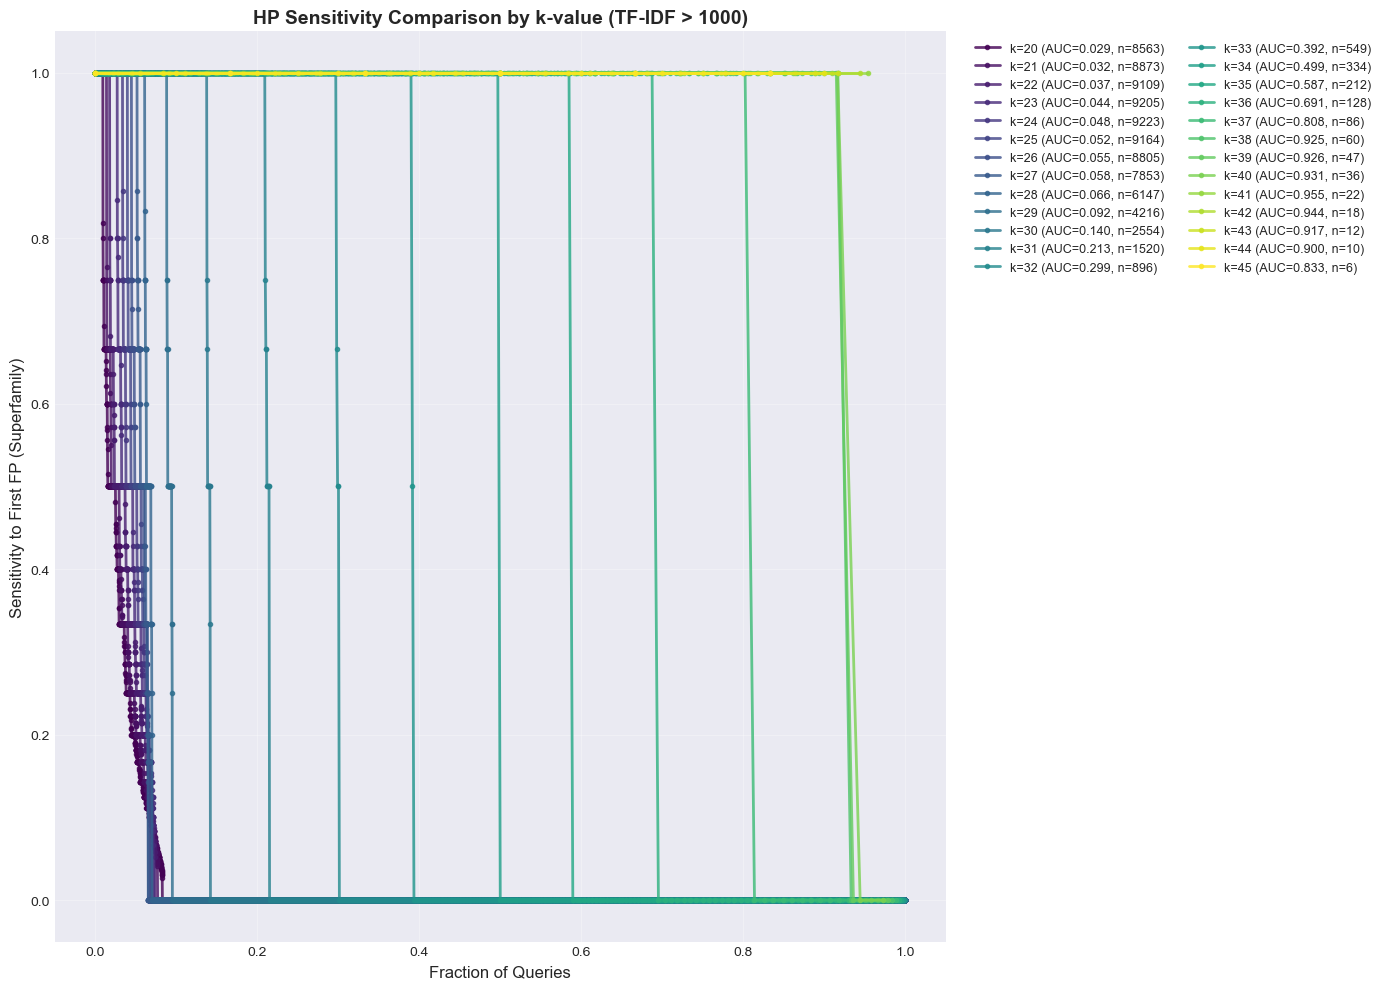

In [ ]:
# Create colormap for k-values using viridis
import matplotlib.cm as cm
k_values_sorted = sorted(hp_data.keys())
colors = cm.viridis(np.linspace(0, 1, len(k_values_sorted)))
k_color_map = {k: colors[i] for i, k in enumerate(k_values_sorted)}

# Plot sensitivity curves for TF-IDF > 1000
print("Plotting sensitivity curves for TF-IDF > 1000")

fig, ax = plt.subplots(figsize=(14, 10))

# Sort results by k
sorted_results = sorted(sensitivity_results, key=lambda x: x['k'])

# Plot each k-value
for result in sorted_results:
    k = result['k']
    auc = result['auc']
    frac = result['frac']
    sens = result['sens']
    n_queries = result['n_queries']
    
    ax.plot(frac, sens, 'o-', label=f"k={k} (AUC={auc:.3f}, n={n_queries})",
            linewidth=2, markersize=3, alpha=0.8, color=k_color_map[k])

ax.set_xlabel('Fraction of Queries', fontsize=12)
ax.set_ylabel('Sensitivity to First FP (Superfamily)', fontsize=12)
ax.set_title('HP Sensitivity Comparison by k-value (TF-IDF > 1000)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hp_k20_30_sensitivity_tfidf_1000.pdf', bbox_inches='tight', dpi=300)
plt.show()

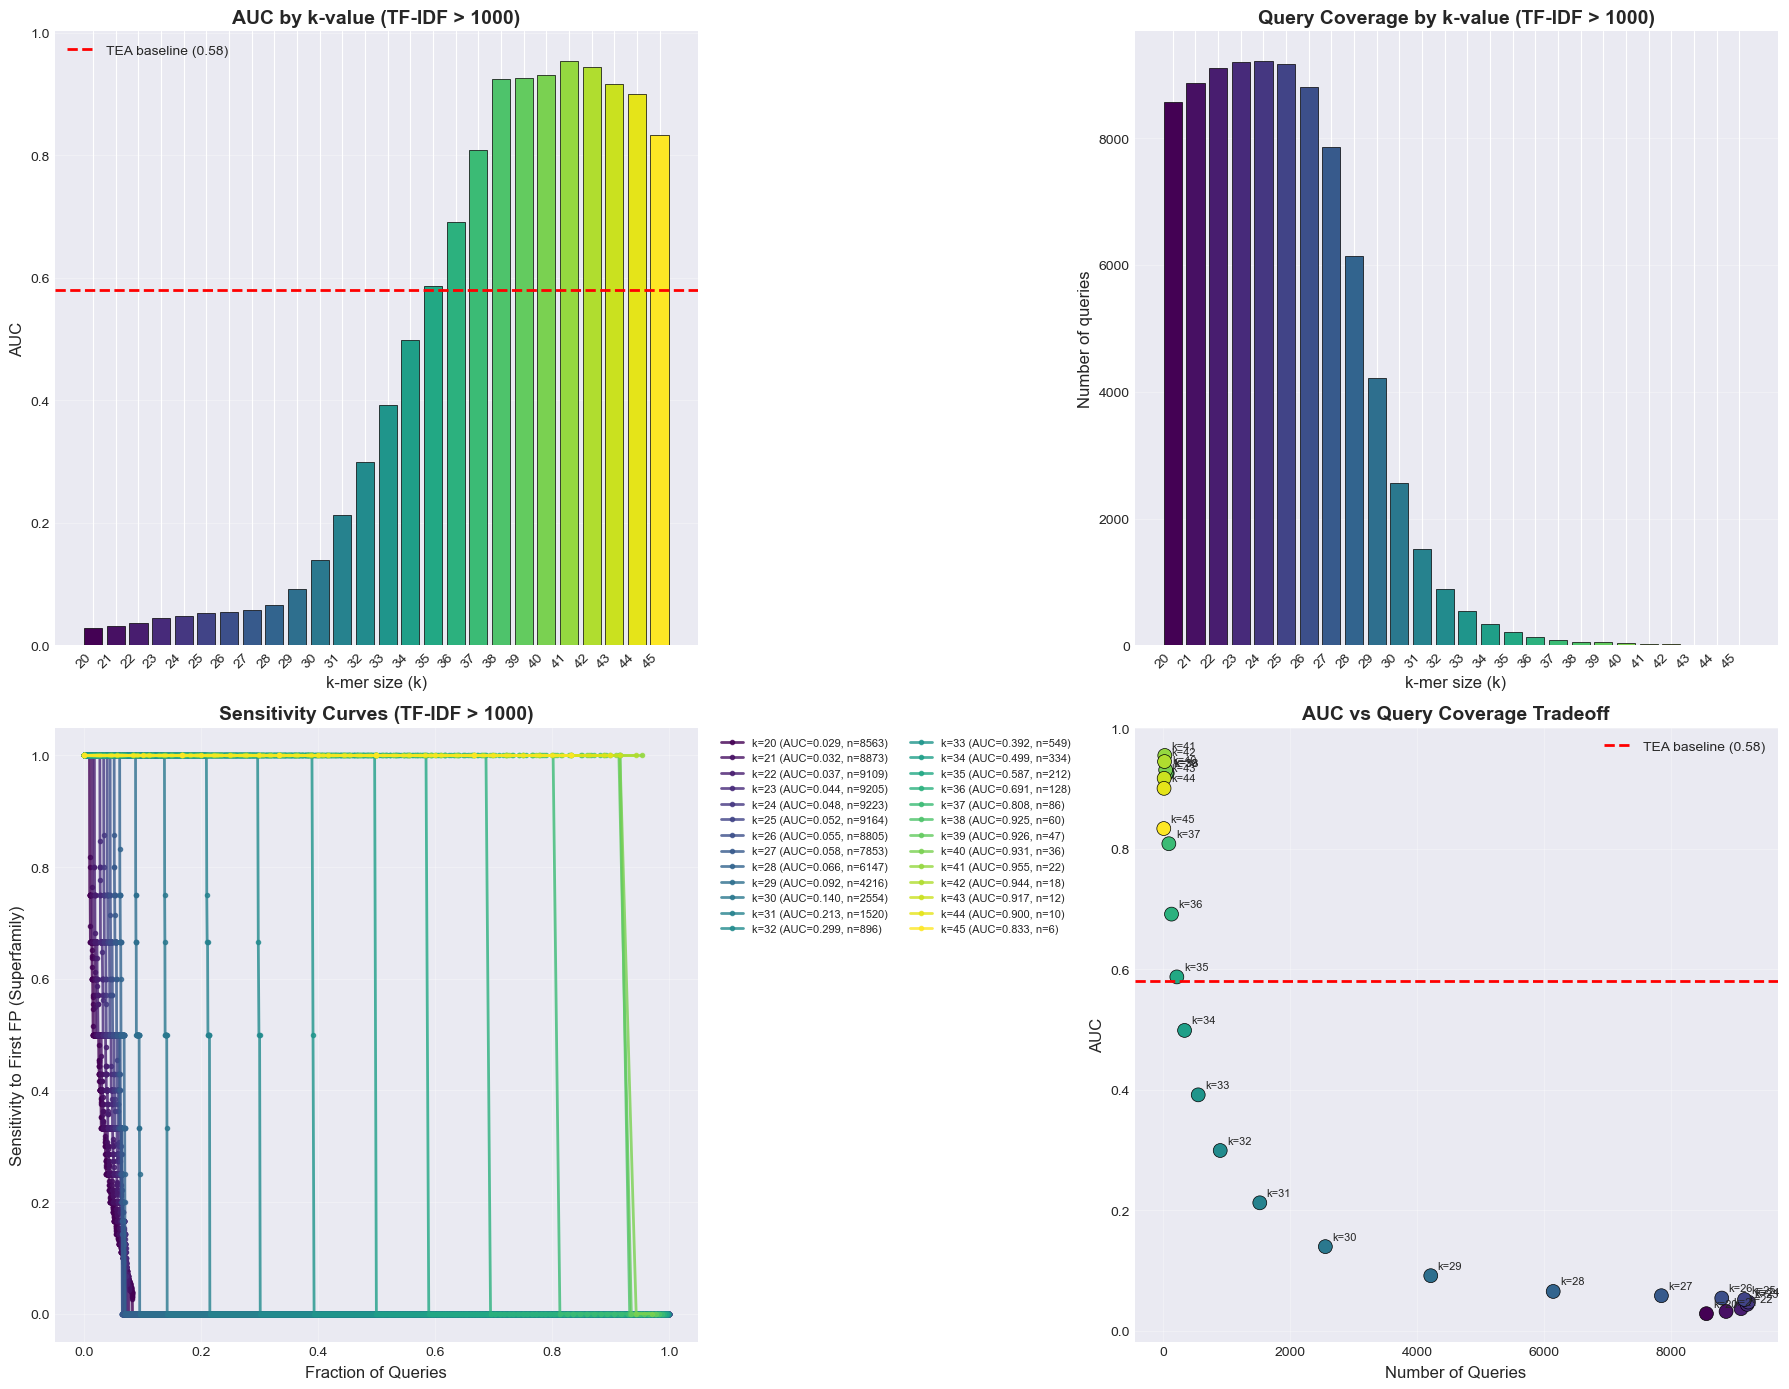

In [ ]:
# Create colormap for k-values using viridis
import matplotlib.cm as cm
k_values_sorted = sorted(hp_data.keys())
colors = cm.viridis(np.linspace(0, 1, len(k_values_sorted)))
k_color_map = {k: colors[i] for i, k in enumerate(k_values_sorted)}

# Create comprehensive comparison plot for TF-IDF > 1000
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: AUC by k-value (bar chart with viridis colors)
ax = axes[0, 0]
k_vals = sens_summary['k'].to_list()
aucs = sens_summary['auc'].to_list()
bar_colors = [k_color_map[k] for k in k_vals]
bars = ax.bar(range(len(k_vals)), aucs, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('AUC by k-value (TF-IDF > 1000)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(k_vals)))
ax.set_xticklabels([str(k) for k in k_vals], rotation=45, ha='right')
ax.axhline(y=0.58, color='red', linestyle='--', linewidth=2, label='TEA baseline (0.58)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Number of queries by k-value (bar chart)
ax = axes[0, 1]
n_queries = sens_summary['n_queries'].to_list()
bars = ax.bar(range(len(k_vals)), n_queries, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('k-mer size (k)', fontsize=12)
ax.set_ylabel('Number of queries', fontsize=12)
ax.set_title('Query Coverage by k-value (TF-IDF > 1000)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(k_vals)))
ax.set_xticklabels([str(k) for k in k_vals], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Sensitivity curves for all k-values
ax = axes[1, 0]
for result in sorted(sensitivity_results, key=lambda x: x['k']):
    k = result['k']
    ax.plot(result['frac'], result['sens'], 'o-', 
            label=f"k={k} (AUC={result['auc']:.3f}, n={result['n_queries']})",
            linewidth=2, markersize=3, alpha=0.8, color=k_color_map[k])

ax.set_xlabel('Fraction of Queries', fontsize=12)
ax.set_ylabel('Sensitivity to First FP (Superfamily)', fontsize=12)
ax.set_title('Sensitivity Curves (TF-IDF > 1000)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Plot 4: AUC vs Number of Queries tradeoff
ax = axes[1, 1]
scatter = ax.scatter(n_queries, aucs, c=[k_color_map[k] for k in k_vals], 
                     s=100, edgecolors='black', linewidth=0.5)
for i, k in enumerate(k_vals):
    ax.annotate(f'k={k}', (n_queries[i], aucs[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Number of Queries', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('AUC vs Query Coverage Tradeoff', fontsize=14, fontweight='bold')
ax.axhline(y=0.58, color='red', linestyle='--', linewidth=2, label='TEA baseline (0.58)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hp_k20_30_comprehensive_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 8. Summary and Recommendations

In [ ]:
# Performance Summary (TF-IDF > 1000)
print("\n" + "="*80)
print("SUMMARY: HP k-value Performance with TF-IDF > 1000")
print("="*80)

# Best k-value by AUC
best_k = max(sensitivity_results, key=lambda x: x['auc'])
print(f"\nBest k-value by AUC:")
print(f"  k={best_k['k']}")
print(f"  AUC: {best_k['auc']:.4f}")
print(f"  Queries: {best_k['n_queries']}")

# K-values that outperform TEA (AUC >= 0.58)
print(f"\nK-values outperforming TEA/FoldSeek (AUC >= 0.58):")
for result in sorted(sensitivity_results, key=lambda x: x['k']):
    if result['auc'] >= 0.58:
        print(f"  k={result['k']}: AUC={result['auc']:.4f}, n_queries={result['n_queries']}")

# All results sorted by AUC
print(f"\n\nAll k-values sorted by AUC (descending):")
print(sens_summary.sort(['auc'], descending=True))

# Save summary
sens_summary.write_csv('hp_k20_30_sensitivity_summary.csv')
print(f"\nSaved summary to hp_k20_30_sensitivity_summary.csv")


SUMMARY: HP k-value Performance with TF-IDF > 1000

Best k-value by AUC:
  k=41
  AUC: 0.9545
  Queries: 22

K-values outperforming TEA/FoldSeek (AUC >= 0.58):
  k=35: AUC=0.5873, n_queries=212
  k=36: AUC=0.6914, n_queries=128
  k=37: AUC=0.8081, n_queries=86
  k=38: AUC=0.9250, n_queries=60
  k=39: AUC=0.9255, n_queries=47
  k=40: AUC=0.9306, n_queries=36
  k=41: AUC=0.9545, n_queries=22
  k=42: AUC=0.9444, n_queries=18
  k=43: AUC=0.9167, n_queries=12
  k=44: AUC=0.9000, n_queries=10
  k=45: AUC=0.8333, n_queries=6


All k-values sorted by AUC (descending):
shape: (26, 4)
┌─────┬───────────┬───────────┬──────────┐
│ k   ┆ threshold ┆ n_queries ┆ auc      │
│ --- ┆ ---       ┆ ---       ┆ ---      │
│ i64 ┆ i64       ┆ i64       ┆ f64      │
╞═════╪═══════════╪═══════════╪══════════╡
│ 41  ┆ 1000      ┆ 22        ┆ 0.954545 │
│ 42  ┆ 1000      ┆ 18        ┆ 0.944444 │
│ 40  ┆ 1000      ┆ 36        ┆ 0.930556 │
│ 39  ┆ 1000      ┆ 47        ┆ 0.925532 │
│ 38  ┆ 1000      ┆ 60        

## 9. Analyze Best Performer: k=41 with TF-IDF > 1000

Examine the 22 queries from the best performing configuration and compare with FoldSeek and TEA.

In [ ]:
# Analyze best performer: k=41 with TF-IDF > 1000
# Get the rocx data for k=41, threshold=1000
best_k = 41
best_threshold = 1000

best_rocx = hp_rocx_results[best_k][best_threshold]
print(f"Best performer: k={best_k}, TF-IDF > {best_threshold}")
print(f"Number of queries: {len(best_rocx)}")
print(f"\nROCX data:")
print(best_rocx)

# Load FoldSeek and TEA results for comparison
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

# Load FoldSeek (tab-separated)
foldseek = pl.read_csv(tea_dir / "foldseek.rocx", separator="\t")
print(f"\nFoldSeek: {len(foldseek)} queries")

# Load TEA (comma-separated)
tea_all = pl.read_csv(tea_dir / "tea_all.rocx", separator=",")
print(f"TEA: {len(tea_all)} queries")

# Get the query names from our best performer
hp_query_names = best_rocx['NAME'].to_list()
print(f"\nHP k={best_k} query names:")
for name in hp_query_names:
    print(f"  {name}")

# Check if these queries exist in FoldSeek and TEA
print(f"\n{'='*80}")
print("COMPARISON WITH FOLDSEEK AND TEA")
print(f"{'='*80}")

# Create comparison DataFrame
comparison_rows = []
for row in best_rocx.iter_rows(named=True):
    query_name = row['NAME']
    scop = row['SCOP']
    hp_sfam = row['SFAM']
    hp_sfamcnt = row['SFAMCNT']
    
    # Check FoldSeek
    fs_match = foldseek.filter(pl.col('NAME') == query_name)
    if len(fs_match) > 0:
        fs_sfam = fs_match['SFAM'][0]
        fs_sfamcnt = fs_match['SFAMCNT'][0]
        fs_detected = True
    else:
        fs_sfam = None
        fs_sfamcnt = None
        fs_detected = False
    
    # Check TEA
    tea_match = tea_all.filter(pl.col('NAME') == query_name)
    if len(tea_match) > 0:
        tea_sfam = tea_match['SFAM'][0]
        tea_sfamcnt = tea_match['SFAMCNT'][0]
        tea_detected = True
    else:
        tea_sfam = None
        tea_sfamcnt = None
        tea_detected = False
    
    comparison_rows.append({
        'NAME': query_name,
        'SCOP': scop,
        'HP_SFAM': hp_sfam,
        'HP_SFAMCNT': hp_sfamcnt,
        'FoldSeek_detected': fs_detected,
        'FoldSeek_SFAM': fs_sfam,
        'FoldSeek_SFAMCNT': fs_sfamcnt,
        'TEA_detected': tea_detected,
        'TEA_SFAM': tea_sfam,
        'TEA_SFAMCNT': tea_sfamcnt
    })

comparison_df = pl.DataFrame(comparison_rows)
print("\nDetailed comparison:")
print(comparison_df)

# Summary statistics
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print(f"Total HP k={best_k} queries: {len(comparison_df)}")
print(f"Also detected by FoldSeek: {comparison_df['FoldSeek_detected'].sum()}")
print(f"Also detected by TEA: {comparison_df['TEA_detected'].sum()}")
print(f"Unique to HP k={best_k} (not in FoldSeek): {(~comparison_df['FoldSeek_detected']).sum()}")
print(f"Unique to HP k={best_k} (not in TEA): {(~comparison_df['TEA_detected']).sum()}")
print(f"Unique to HP k={best_k} (not in either): {((~comparison_df['FoldSeek_detected']) & (~comparison_df['TEA_detected'])).sum()}")

# Compare performance where all methods have results
both_have = comparison_df.filter(pl.col('FoldSeek_detected') & pl.col('TEA_detected'))
print(f"\nQueries where all 3 methods have results: {len(both_have)}")

if len(both_have) > 0:
    print("\nPerformance comparison for shared queries:")
    print(both_have.select(['NAME', 'SCOP', 'HP_SFAM', 'FoldSeek_SFAM', 'TEA_SFAM']))
    
    # Calculate wins
    hp_beats_fs = (both_have['HP_SFAM'] > both_have['FoldSeek_SFAM']).sum()
    hp_beats_tea = (both_have['HP_SFAM'] > both_have['TEA_SFAM']).sum()
    print(f"\nHP k={best_k} beats FoldSeek: {hp_beats_fs}/{len(both_have)}")
    print(f"HP k={best_k} beats TEA: {hp_beats_tea}/{len(both_have)}")

# Save the comparison to CSV
comparison_df.write_csv(f'hp_k{best_k}_tfidf{best_threshold}_comparison_with_foldseek_tea.csv')
print(f"\nSaved comparison to: hp_k{best_k}_tfidf{best_threshold}_comparison_with_foldseek_tea.csv")

Best performer: k=41, TF-IDF > 1000
Number of queries: 22

ROCX data:
shape: (22, 9)
┌─────────┬───────────┬─────┬────────┬───┬─────────┬──────┬─────────┬─────┐
│ NAME    ┆ SCOP      ┆ FAM ┆ FAMCNT ┆ … ┆ SFAMCNT ┆ FOLD ┆ FOLDCNT ┆ FP  │
│ ---     ┆ ---       ┆ --- ┆ ---    ┆   ┆ ---     ┆ ---  ┆ ---     ┆ --- │
│ str     ┆ str       ┆ f64 ┆ i64    ┆   ┆ i64     ┆ f64  ┆ i64     ┆ i64 │
╞═════════╪═══════════╪═════╪════════╪═══╪═════════╪══════╪═════════╪═════╡
│ d3fxwa_ ┆ d.144.1.7 ┆ 0.0 ┆ 0      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 1   │
│ d1w7ja2 ┆ c.37.1.9  ┆ 0.0 ┆ 0      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 1   │
│ d7rcaa1 ┆ d.258.1.1 ┆ 1.0 ┆ 2      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 0   │
│ d6pyma_ ┆ b.47.1.1  ┆ 1.0 ┆ 2      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 0   │
│ d1epwa3 ┆ d.92.1.7  ┆ 0.0 ┆ 0      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 1   │
│ …       ┆ …         ┆ …   ┆ …      ┆ … ┆ …       ┆ …    ┆ …       ┆ …   │
│ d2ap2a1 ┆ b.1.1.1   ┆ 1.0 ┆ 2      ┆ … ┆ 2       ┆ 1.0  ┆ 2       ┆ 0   │
│ d

In [ ]:
# Show the raw k=41 data with TF-IDF > 1000
# This shows the actual query-target pairs detected
k41_data = hp_data[41]
k41_filtered = k41_data.filter(pl.col('tfidf') > 1000)

print(f"Raw HP k=41 results with TF-IDF > 1000:")
print(f"Total comparisons: {len(k41_filtered)}")

# Select key columns to display
cols_to_show = [
    'query_name', 'target_name', 
    'n_intersecting_hashes', 'jaccard', 'max_containment', 'tfidf',
    'family_match', 'superfamily_match', 'fold_match',
    'query_scop', 'target_scop'
]

# Only show columns that exist
cols_to_show = [c for c in cols_to_show if c in k41_filtered.columns]

print(f"\nDetailed results:")
print(k41_filtered.select(cols_to_show).sort('tfidf', descending=True))

# Save the full results
k41_filtered.write_csv(f'hp_k41_tfidf1000_raw_results.csv')
print(f"\nSaved raw results to: hp_k41_tfidf1000_raw_results.csv")

# Show unique queries
unique_queries = k41_filtered['query_name'].unique().sort()
print(f"\nUnique queries ({len(unique_queries)}):")
for q in unique_queries:
    n_targets = len(k41_filtered.filter(pl.col('query_name') == q))
    n_sf = len(k41_filtered.filter((pl.col('query_name') == q) & pl.col('superfamily_match')))
    print(f"  {q}: {n_targets} targets ({n_sf} superfamily matches)")

Raw HP k=41 results with TF-IDF > 1000:
Total comparisons: 29

Detailed results:
shape: (29, 9)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ query_nam ┆ target_na ┆ n_interse ┆ jaccard  ┆ … ┆ tfidf     ┆ family_ma ┆ superfami ┆ fold_matc │
│ e         ┆ me        ┆ cting_has ┆ ---      ┆   ┆ ---       ┆ tch       ┆ ly_match  ┆ h         │
│ ---       ┆ ---       ┆ hes       ┆ f64      ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│ str       ┆ str       ┆ ---       ┆          ┆   ┆           ┆ bool      ┆ bool      ┆ bool      │
│           ┆           ┆ i64       ┆          ┆   ┆           ┆           ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ d1w7ja2   ┆ d6ui4a_   ┆ 13        ┆ 0.009782 ┆ … ┆ 6619.7031 ┆ false     ┆ true      ┆ true      │
│ c.37.1.9  ┆ c.37.1.0  ┆           ┆          ┆   ┆ 7         ┆           ┆           ┆        

In [ ]:
# Save the queries that HP k=41 finds but FoldSeek doesn't
hp_unique_vs_foldseek = comparison_df.filter(~pl.col('FoldSeek_detected'))
print(f"Queries found by HP k=41 but NOT by FoldSeek: {len(hp_unique_vs_foldseek)}")
print(hp_unique_vs_foldseek)

# Get the full raw data for these queries
unique_query_names = hp_unique_vs_foldseek['NAME'].to_list()
k41_unique_raw = k41_filtered.filter(pl.col('query_name').str.contains('|'.join([f'^{q}' for q in unique_query_names])))

# Actually, let's extract query names properly - they might have additional info
# The NAME in rocx is like 'd1abc_' but query_name might be 'd1abc_ a.1.2.3 (A:1-100) description'
# Let's match on the first part
k41_unique_raw = k41_filtered.filter(
    pl.col('query_name').str.extract(r'^(\S+)', 1).is_in(unique_query_names)
)

print(f"\nRaw comparisons for these {len(unique_query_names)} queries: {len(k41_unique_raw)} rows")

# Save to files
hp_unique_vs_foldseek.write_csv('hp_k41_unique_vs_foldseek_rocx.csv')
k41_unique_raw.write_csv('hp_k41_unique_vs_foldseek_raw.csv')

print(f"\nSaved files:")
print(f"  - hp_k41_unique_vs_foldseek_rocx.csv (ROCX format with {len(hp_unique_vs_foldseek)} queries)")
print(f"  - hp_k41_unique_vs_foldseek_raw.csv (raw comparisons with {len(k41_unique_raw)} rows)")

# Also show what SCOPe classes these belong to
print(f"\nSCOPe classifications of unique queries:")
for row in hp_unique_vs_foldseek.iter_rows(named=True):
    print(f"  {row['NAME']}: {row['SCOP']} (SFAM sensitivity: {row['HP_SFAM']:.2f}, SFAMCNT: {row['HP_SFAMCNT']})")

Queries found by HP k=41 but NOT by FoldSeek: 17
shape: (17, 10)
┌─────────┬───────────┬─────────┬────────────┬───┬────────────┬────────────┬──────────┬────────────┐
│ NAME    ┆ SCOP      ┆ HP_SFAM ┆ HP_SFAMCNT ┆ … ┆ FoldSeek_S ┆ TEA_detect ┆ TEA_SFAM ┆ TEA_SFAMCN │
│ ---     ┆ ---       ┆ ---     ┆ ---        ┆   ┆ FAMCNT     ┆ ed         ┆ ---      ┆ T          │
│ str     ┆ str       ┆ f64     ┆ i64        ┆   ┆ ---        ┆ ---        ┆ f64      ┆ ---        │
│         ┆           ┆         ┆            ┆   ┆ i64        ┆ bool       ┆          ┆ i64        │
╞═════════╪═══════════╪═════════╪════════════╪═══╪════════════╪════════════╪══════════╪════════════╡
│ d3fxwa_ ┆ d.144.1.7 ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ d1w7ja2 ┆ c.37.1.9  ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ d7rcaa1 ┆ d.258.1.1 ┆ 1.0     ┆ 2          ┆ … ┆ null       ┆ false      ┆ null     ┆ null       │
│ d6pyma_ ┆ b.47.1.1  ┆ 1.

In [ ]:
# Save summary statistics
summary_df.write_csv('hp_k20_30_summary.csv')
sens_summary.write_csv('hp_k20_30_sensitivity_summary.csv')
hash_summary.write_csv('hp_k20_30_hash_summary.csv')

print("\nSummary files saved:")
print("  - hp_k20_30_summary.csv")
print("  - hp_k20_30_sensitivity_summary.csv")
print("  - hp_k20_30_hash_summary.csv")


Summary files saved:
  - hp_k20_30_summary.csv
  - hp_k20_30_sensitivity_summary.csv
  - hp_k20_30_hash_summary.csv


## 10. Verdict

**The "best k=41" result is an artifact of a collapsing query set and should not be carried
forward.** AUC and coverage move in opposite directions across the whole sweep, and they do so
violently: k=20 gives AUC 0.0287 on 8,563 queries, k=24 gives 0.0479 on 9,223, and by k=41 the AUC
is 0.9545 on **22 queries**. Every k that clears the TEA/FoldSeek bar of 0.58 does so with between
6 and 212 queries. Nothing in this sweep shows kmerseek performing well; it shows the tf-idf > 1000
filter removing queries until only easy ones remain.

**The remaining queries are easy by construction.** In the k=41 ROCX table most queries have
SFAMCNT=2, meaning their superfamily contains two members total, so retrieving one true positive
before the first false positive scores 1.0. An AUC built mostly from families of size 2 is not
comparable to FoldSeek's 0.5743 over 5,713 queries, which is dominated by large families. The
comparison in section 8 puts these two numbers side by side, and they do not belong on the same
axis.

**Only 29 raw comparisons survive at k=41.** Of those, several are family mismatches that are
superfamily and fold matches (`d1w7ja2` c.37.1.9 against `d6ui4a_` c.37.1.0, jaccard 0.0098, 13
intersecting hashes), which is the `.0`-versus-classified SCOPe annotation artifact rather than a
real cross-family call. Jaccard values in the 0.002-0.010 range on 2 to 13 shared hashes are thin
evidence for any individual pair.

**The 17 queries FoldSeek misses are the only durable output here.** They are saved to
`hp_k41_unique_vs_foldseek_rocx.csv` and are picked up by
[060](./060-hp-k41-unique-vs-foldseek-analysis.ipynb). Their value is as a candidate list, not as a
benchmark score.

**Methodological takeaway for the later notebooks.** Any k-sweep on this benchmark has to report
n_queries next to every AUC, and a minimum-coverage floor has to be fixed before the sweep rather
than after. Notebooks 067 and 075 adopt exactly that (1% of 14,873 as `NQUERY_MIN`), which is the
correction this notebook motivates. The tf-idf > 1000 pre-filter used throughout here was also
dropped in later work, and notebook 116 later shows tf-idf to be the weakest ranking metric
available (ROC AUC 0.568), so the filter that produced this whole sweep was selecting on a
near-uninformative axis.